In [ ]:
# testing time-dependent coupling with heat markers 
# first just checking pt heat markers works/scaling
# then compare optimal control with time dependent coupling 

import oqupy 
import oqupy.operators as op 

dt = 0.25
epsrel_pow = 8
epsrel = 10**(-epsrel_pow)  # convert to float
tcut_tti=500
tcut_pt=20

print(f'Running with dt : {dt} ps, epsrel power: -{epsrel_pow}')

pt_parameters = {'epsrel':epsrel,
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':dt}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w

# bare pt 
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)

bath = oqupy.Bath(op.sigma("z")/2.0, correlations)

parameters_pt=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut_pt/dt)+1)
parameters_tti=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut_tti/dt)+1)

# counting field dressed pt
u=0.01


correlationscf=oqupy.bath_correlations.CustomCountingSD_analytical(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)


bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

# comparing time dependent coupling for tempo and pt-tempo cases with TTI case for constant coupling first --->

Running with dt : 0.25 ps, epsrel power: -8


In [33]:
from oqupy.pt_tempo import pt_tempo_counting_compute,pt_tempo_compute
import numpy as np
# time dependent pt_tempo
t_end=20
num_steps = int(t_end / dt)
td_coupling = 1*np.ones(num_steps)#np.linspace(0.0000001,1,num_steps)

# time dependent PT tempo

pt_cf_td_tempo= pt_tempo_counting_compute(bathcf,start_time=0.0,parameters=parameters_pt,alpha_t=td_coupling,end_time=t_end)

pt_td_tempo= pt_tempo_compute(bath,start_time=0.0,parameters=parameters_pt,alpha_t=td_coupling,end_time=t_end)

--> PT-TEMPO computation:
100.0%   80 of   80 [########################################] 00:00:15
Elapsed time: 15.5s
--> PT-TEMPO computation:
100.0%   80 of   80 [########################################] 00:00:12
Elapsed time: 12.0s


In [34]:
from oqupy.tti_tempo import TTITempoCounting, TTITempo

# constant coupling tti_tempo
# time dependent tti_tempo
pt= TTITempoCounting(bathcf,start_time=0.0,parameters=parameters_tti)
pt_cf_tti= pt.get_process_tensor() # process tensor generated from tti code with counting field dressed correlations

pt= TTITempo(bath,start_time=0.0,parameters=parameters_tti)
pt_tti= pt.get_process_tensor()

building influence functional: 100%|██████████| 2001/2001 [00:01<00:00, 1205.31it/s]


rank  76


building influence functional: 100%|██████████| 2001/2001 [00:01<00:00, 1367.03it/s]

rank  72


In [26]:
import matplotlib.pyplot as plt

def hamiltonian_t(t):
    return op.sigma("x")/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

tcut_tempo=20
parameters_tempo=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut_tempo/dt)+1)


dynamics_tempo = oqupy.tempo_compute(system=system,
                               bath=bath,
                               initial_state=Rho_0,
                               start_time=0.0,
                               alpha_t=td_coupling,
                               end_time=t_end,
                               parameters=parameters_tempo,
                               unique=False)



--> TEMPO computation:


100.0%   80 of   80 [########################################] 00:04:26
Elapsed time: 266.4s


In [30]:
parameters_tempo=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut_tempo/dt)+1)


dynamics_tempocf_td = oqupy.tempo_compute(system=system,
                               bath=bathcf,
                               initial_state=Rho_0,
                               start_time=0.0,
                               alpha_t=td_coupling,
                               end_time=t_end,
                               parameters=parameters_tempo,
                               unique=False)

--> TEMPO computation:
100.0%   80 of   80 [########################################] 00:04:38
Elapsed time: 278.3s


In [35]:
dynamics_cf_tti = oqupy.compute_dynamics(
    process_tensor=pt_cf_tti,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamics_cf_td_pt_tempo = oqupy.compute_dynamics(
    process_tensor=pt_cf_td_tempo,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:03
Elapsed time: 3.2s
--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:03
Elapsed time: 3.4s


In [36]:
dynamics_tti = oqupy.compute_dynamics(
    process_tensor=pt_tti,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamics_td_pt_tempo = oqupy.compute_dynamics(
    process_tensor=pt_td_tempo,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:03
Elapsed time: 3.1s
--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:03
Elapsed time: 3.2s


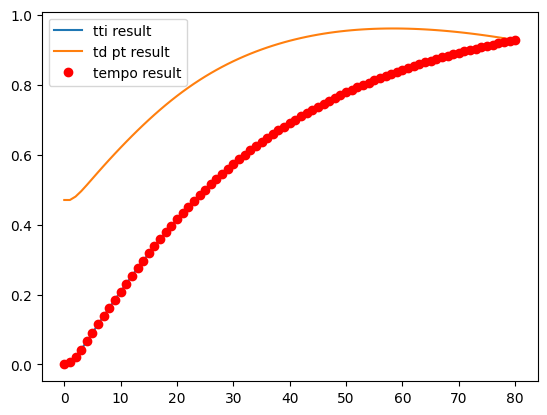

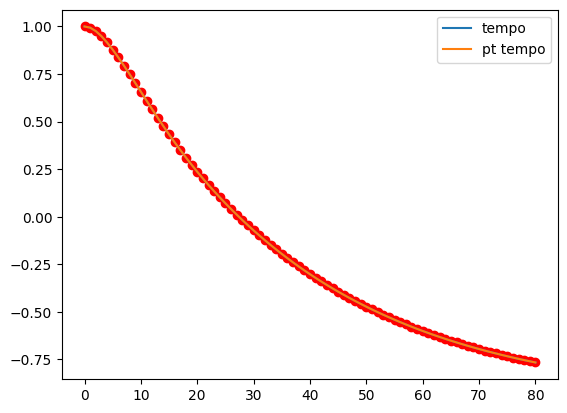

In [ ]:
final_Q_tempo= dynamics_tempocf_td.states.trace(axis1=1, axis2=2).imag / u

final_Q_tti= dynamics_cf_tti.states.trace(axis1=1, axis2=2).imag / u

final_Q_td = dynamics_cf_td_pt_tempo.states.trace(axis1=1, axis2=2).imag / u
# dynamics all agree for constant td coupling 
sx_tempo=dynamics_tempo.expectations(op.sigma("x"))
sx_tti=dynamics_tti.expectations(op.sigma("x"))
sx_td=dynamics_td_pt_tempo.expectations(op.sigma("x"))


# td pt result is wrong - need to check code probably bug 
plt.plot(final_Q_tti,label='tti result')
plt.plot(final_Q_td,label='td pt result')
plt.plot(final_Q_tempo,'ro', label = 'tempo result')
plt.legend()
plt.show()

plt.plot(sx_tti[1],'ro')
plt.plot(sx_tempo[1],label="tempo")
plt.plot(sx_td[1],label="pt tempo")
plt.legend()
plt.show()

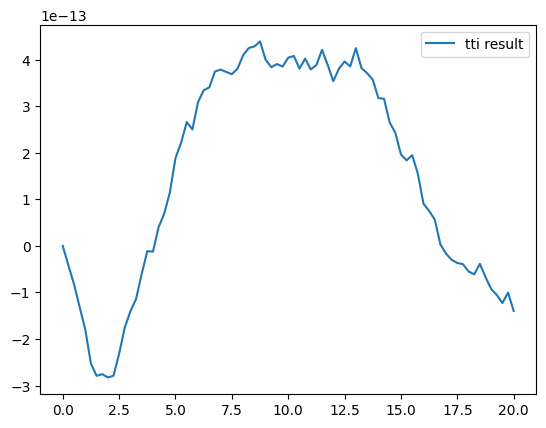

In [7]:
plt.plot(np.linspace(0,t_end,len(final_Q_tti)),final_Q_tti,label='tti result')
#plt.plot(np.linspace(0,t_end,len(final_Q_tempo)),final_Q_tempo,label='tempo result')
plt.legend()
plt.show()

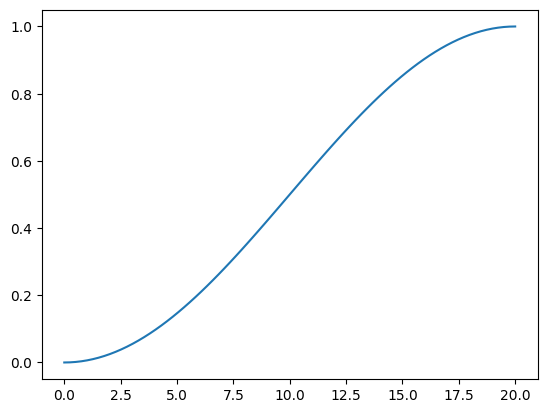

In [8]:
# now try smooth ramp up in the first 50ps 

def smoothstep(n): # smooth 0 to 1
    x = np.linspace(0, 1, n)
    gamma=1
    x = x**gamma
    return 0.5 * (1 - np.cos(np.pi * x))


coupling_smoothed = td_coupling.copy()
n_ramp=80

w = smoothstep(n_ramp)

coupling_smoothed[:n_ramp] = w
plt.plot(np.linspace(0,t_end,num_steps),coupling_smoothed)

In [9]:
print(coupling_smoothed.shape)

(80,)


--> TEMPO computation:


100.0%   80 of   80 [########################################] 00:01:43
Elapsed time: 103.6s


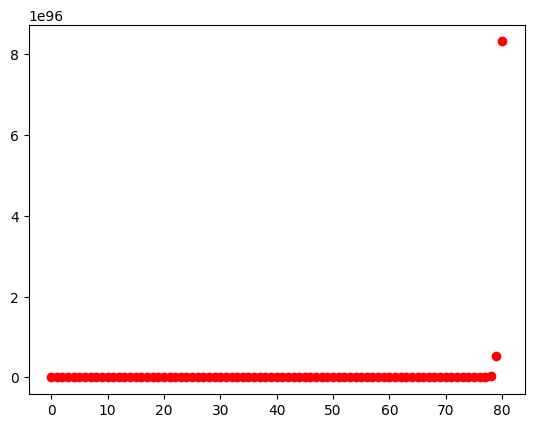

In [10]:

def hamiltonian_t(t):
    return -(1-t/2000)*op.sigma("x")/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

tcut_tempo=20
parameters_tempo=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut_tempo/dt)+1)

dynamics_tempo_smooth = oqupy.tempo_compute(system=system,
                               bath=bath,
                               initial_state=Rho_0,
                               start_time=0.0,
                               alpha_t=coupling_smoothed,
                               end_time=t_end,
                               parameters=parameters_pt,
                               unique=False)

t,final_Q_tempo= dynamics_tempo_smooth.expectations(op.sigma("x"))#dynamics_tempo_smooth.states.trace(axis1=1, axis2=2).imag / u

plt.plot(final_Q_tempo,'ro', label = 'tempo result smooth')

plt.show()

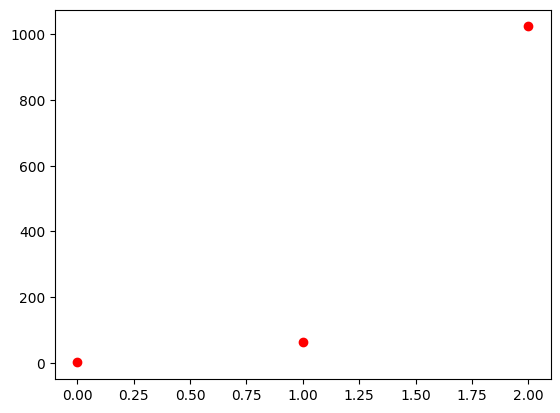

In [11]:
plt.plot(final_Q_tempo[:3],'ro', label = 'tempo result smooth')

plt.show()

In [12]:
# time dependent pt_tempo
t_end=20
num_steps = int(t_end / dt)
td_coupling = np.ones(num_steps)

pt_cf_td_smooth= pt_tempo_counting_compute(bathcf,start_time=0.0,parameters=parameters_pt,alpha_t=coupling_smoothed,end_time=t_end)

--> PT-TEMPO computation:
100.0%   80 of   80 [########################################] 00:00:13
Elapsed time: 13.4s


--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:04
Elapsed time: 5.0s


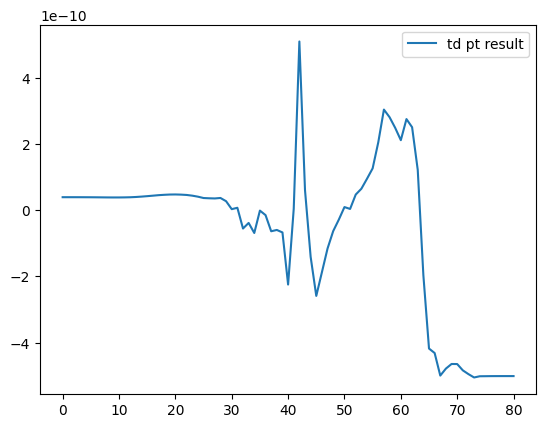

In [13]:
dynamicstd_smooth = oqupy.compute_dynamics(
    process_tensor=pt_cf_td_smooth,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)


final_Q_td_smooth = dynamicstd.states.trace(axis1=1, axis2=2).imag / u


plt.plot(final_Q_td_smooth,label='td pt result')
#plt.plot(final_Q_tempo,'ro', label = 'tempo result')
plt.legend()
plt.show()